In [1]:
from Configurations.imports import *

In [21]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000, n_features=2, n_classes=2, n_redundant=0, random_state=45)

<Axes: >

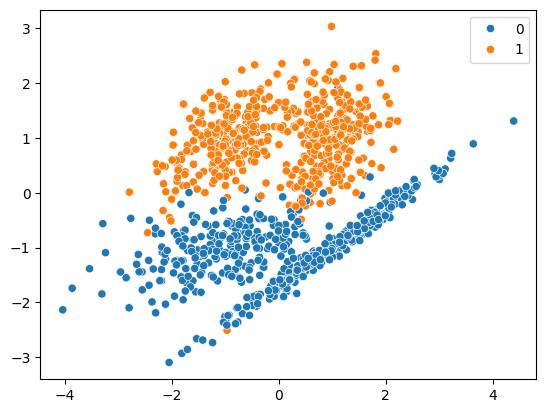

In [22]:
# try to visualize this points
sns.scatterplot(x=X.T[0], y=X.T[1], hue=y)

In [23]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y)

In [ ]:
from sklearn.svm import SVC
classifier = SVC(kernel="linear")

classifier.fit(x_train, y_train,)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [28]:
# Make the prediction
y_pred = classifier.predict(x_test)

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.95      0.96       113
           1       0.96      0.97      0.96       137

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250

[[107   6]
 [  4 133]]


In [60]:
# Hyper parameter tuning
param_grid = {
    "C":[0.1, 1, 10, 0.01, 100, 1000],
    "gamma":[0.1, 0.01, 0.001, 0.0001],
    "kernel":["rbf","linear","poly","sigmoid"]
}

In [62]:
from sklearn.svm import SVC
model = SVC()

from sklearn.model_selection import GridSearchCV
search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, refit=True, verbose=3)

search.fit(x_train, y_train)

Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.960 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.973 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.987 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.947 total time=   0.0s
[CV 1/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.947 total time=   0.0s
[CV 2/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.960 total time=   0.0s
[CV 3/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.967 total time=   0.0s
[CV 4/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.980 total time=   0.0s
[CV 5/5] END ...C=0.1, gamma=0.1, kernel=linear;, score=0.933 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.1, kernel=poly;, score=0.833 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.1, kernel=poly

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [0.1, 0.01, ...], 'kernel': ['rbf', 'linear', ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1000


In [64]:
search.best_params_

{'C': 1000, 'gamma': 0.01, 'kernel': 'rbf'}

'rbf'